# List 2

## Dataset

In [42]:
from torchvision.datasets import Flowers102
from torch.utils.data import DataLoader, ConcatDataset

import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

flowers_train = Flowers102(root='./data', download=True, transform=transform, split='train')
flowers_val = Flowers102(root='./data', download=True, transform=transform, split='val')
flowers_test = Flowers102(root='./data', download=True, transform=transform, split='test')

flowers_dataset = ConcatDataset([flowers_train, flowers_val, flowers_test])
dataloader = DataLoader(flowers_dataset, batch_size=32, shuffle=True)

sample_img, sample_label = flowers_dataset[0]
print(f"Total dataset size: {len(flowers_dataset)}")
print(f"Number of classes: {len(flowers_train.classes)}")
print(f"Sample image shape: {sample_img.shape}")


Total dataset size: 8189
Number of classes: 102
Sample image shape: torch.Size([3, 224, 224])


# Task 0: Do we need Transfer Learning?

## 1. 
Train a small CNN to classify the images. What results have you got? How much time did it
take? Log your results after each epoch on both the training and validation sets to monitor
progress. Provide visualizations that support your answers. You can use wandb or any other
tool.

In [43]:
import torch
from torch.utils.data import random_split
import time

import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# split ds
trainval_size = int(0.8 * len(flowers_dataset))
test_size = len(flowers_dataset) - trainval_size
train_dataset, test_dataset = random_split(flowers_dataset, [trainval_size, test_size])

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])


test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [44]:
class ExampleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(ExampleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Fully connected layers
        self.c = 56*56*16
        self.fc1 = nn.Linear(self.c, 1024) # Flatten (512 * 7 * 7) features
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, self.c) # Flatten the tensor
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # logits for all classes
        return x


In [45]:
model = ExampleCNN(num_classes=102).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []
start_time = time.time()

for epoch in tqdm(range(num_epochs), desc="Training"):
    # train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # val
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    tqdm.write(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
               f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTraining time: {total_time:.2f} seconds")


Training:   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

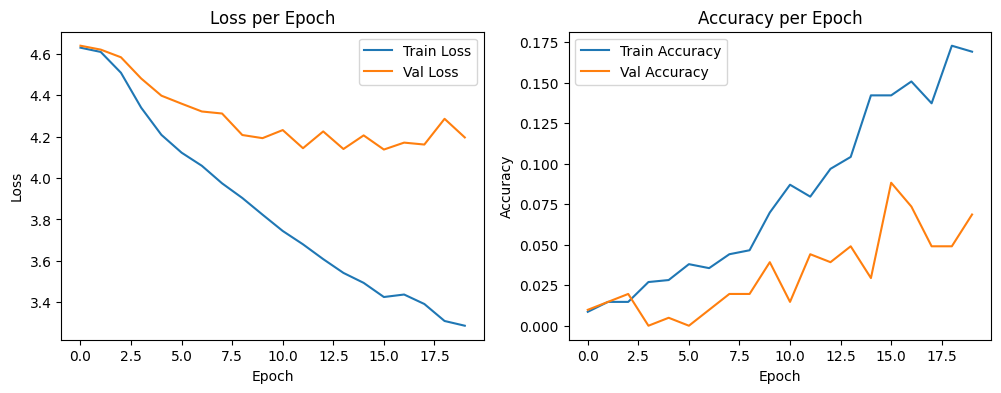

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss per Epoch')

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy per Epoch')

plt.show()


## 2. 
What if we had only 10 percent of the labeled data for training (∼ 650 examples in total)?

## 3. 
Try to train a VGG-13 model on the considered data. How much time does it take? What
accuracy can you get? Monitor the results as previously. You can stop if the training time
exceeds 20 minutes.

## 4. 
Look into the paper proposing the VGG-13 model (https://arxiv.org/pdf/1409.1556). What
dataset has it been pretrained on? What’s the size of this dataset? How much time did it take?